# LOAD LIBRARIES

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from datetime import datetime
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet

# CONFIGURATION

In [21]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'NEE'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = True
LOG_TRANSFORM = False
ADD_ID = False
UNDERSAMPLE = False
PERMUTATION_SEL = True
RFE_SEL = True

# LOAD DATA

In [22]:
data_main = fluxes = load_parquet(filepath=r"../81.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))

data_main

Loaded .parquet file ../81.1_GapFillingDataset.parquet (0.332 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,NEE_U50_f_reddyproc,GPP_U50_f_reddyproc,Reco_U50_reddyproc,parcel,parcel_certainty,SW_IN_POT,prec,ta,ppfd,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,1.991226,-0.238835,1.752390,B,certain,0.0,0.0,5.333333,0.0,...,-1.485105,-1.116706,-1.152150,-0.275176,-0.379151,2.956382,-1.867139,0.684108,-0.057099,-0.193433,-0.188894,0.055964,-1.641550,-0.086146,0.576043
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,2.035776,-0.203400,1.832376,B,certain,0.0,0.0,5.966667,0.0,...,-1.413669,-1.202539,-1.002316,-0.315639,-0.100172,2.819366,-3.607107,0.860526,-0.241229,-0.051464,0.009568,0.016644,-2.340741,0.001028,0.291943
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,2.026159,-0.210755,1.815404,B,certain,0.0,0.0,5.833333,0.0,...,-1.482971,-1.423575,-1.251268,0.154263,0.054827,2.845686,-2.065147,0.363886,0.902289,-0.146880,0.084459,0.138010,-0.829823,0.242660,0.618842
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,2.026159,-0.206519,1.819640,B,certain,0.0,0.0,5.866667,0.0,...,-1.613288,-1.456775,-1.194985,0.190084,0.205121,2.216312,-2.011537,0.459781,0.395772,-0.234554,-0.023746,0.307449,-0.724752,0.260016,0.686303
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,2.025592,-0.218648,1.806944,B,certain,0.0,0.0,5.766667,0.0,...,-1.522183,-1.730865,-1.054997,0.243881,0.243286,1.087768,-1.790441,0.750873,1.037005,-0.187335,-0.028905,0.178615,-0.724348,0.032634,0.695635
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,15.833333,0.0,...,0.564180,1.105808,0.251504,0.137646,0.269348,-0.182687,-1.770683,-2.475835,-0.177535,-1.379082,-1.916712,-1.061214,-4.208609,-5.629534,-3.817729
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,15.733333,0.0,...,-0.058895,1.185266,0.415243,-0.006586,0.174141,-0.309516,-4.491630,-2.066168,-1.321539,-1.091476,-1.879544,-0.962736,-4.909742,-6.854152,-4.700644
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,0.0,16.200000,0.0,...,-0.417110,0.829382,0.121118,0.319431,0.265461,-0.070498,-5.166902,-3.647422,-1.775911,-1.190896,-1.739450,-0.961502,-4.913663,-6.580284,-4.667567


# CLEAN DATA

In [23]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')

# Remove some variables that cannot mechanistically be related to N2O flux or hard to explain 
prefix = ('Reco', 'GPP')
inside = ('parcel')
to_drop = [c for c in data.columns if c.startswith(prefix) or inside in c]
data.drop(columns=to_drop, inplace=True)
print(f"Dropped {len(to_drop)} columns considered not to be relevant for the target based on knowledge: {to_drop}")

# Keep only variables of the chosen categories
# prefix = ('wfps', 'ts', 'prec', 'GPP', 'n_decay', 'NEE', 'Reco', 'timesince', TARGET)
# to_keep = [c for c in data.columns if c.startswith(prefix)]
# data = data[to_keep].copy()
# to_remove = [c for c in data.columns if 'parcelA' in c or 'parcelB' in c]
# data.drop(columns=to_remove, inplace=True)

# Remove any flux variable with target flux except for the target itself
to_drop = [col for col in data.columns if TARGET_FLUX in col]
# Leave the target!
to_drop.remove(TARGET)
data.drop(columns=to_drop, inplace=True)

def clean_data(df, threshold=0.05):
    """Remove columns with too many missing values and non-numeric columns."""
    dropped_missing = df.columns[df.isna().mean() > threshold].tolist()
    df = df.drop(columns=dropped_missing)
    dropped_non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    df = df.select_dtypes(include=[np.number])
    print(f"\nDropped {len(dropped_missing)} due to missing values: {dropped_missing}")
    print(f"Dropped {len(dropped_non_numeric)} non-numeric columns: {dropped_non_numeric}")
    
    return df

data = clean_data(data)

data

The target variable is NEE_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 5.646989835809226

Keeping only data when we are highly confident on the parcel attribution
Dropped 48 columns considered not to be relevant for the target based on knowledge: ['GPP_U50_f_reddyproc', 'Reco_U50_reddyproc', 'parcel', 'parcel_certainty', 'n_decay_linear_parcelA', 'n_decay_linear_parcelB', 'n_decay_logistic_parcelA', 'n_decay_logistic_parcelB', 'n_decay_exponential_parcelA', 'n_decay_exponential_parcelB', 'n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB', 'n_decay_timed_parcelA', 'n_decay_timed_parcelB', 'timesince_fert_parcelA', 'timesince_fert_parcelB', 'fert_parcelA_timed', 'fert_parcelB_timed', 'GPP_U50_f_reddyproc_lag3h', 'GPP_U50_f_reddyproc_lag6h', 'GPP_U50_f_reddyproc_lag9h', 'Reco_U50_reddyproc_lag3h', 'Reco_U50_reddyproc_lag6h', 'Reco_U50_reddyproc_lag9h', 'GPP_U50_f_reddyproc_roll3hsum', 'GPP_U50_f_reddyproc_roll6hsum', 'GPP_U50_f_reddyproc_roll9hsum', 'Reco

,NEE_L3.3_CUT_50_QCF0,SW_IN_POT,prec,ta,ppfd,sw_in,rh,timesince_prec,vpd,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 11:15:00,0.870527,508.623,0.238,3.166667,100.485834,49.333333,95.516667,0.0,0.034392,4.214833,6.794001,7.766860,50.003806,56.279186,46.719290,...,1.337738,-1.317629,-1.124065,-0.114594,-0.332553,-0.728411,3.107422,2.125116,2.928839,0.191085,0.508545,1.199013,0.861383,1.659645,2.910261
2023-11-22 11:45:00,0.844507,531.452,0.000,3.043333,78.235791,38.666667,95.280000,1.0,0.035892,3.948499,6.777297,7.739503,49.749778,56.502881,45.122243,...,1.354507,-1.310291,-1.103999,-0.151393,-0.363302,-0.746003,3.178569,1.489788,2.715081,0.431137,0.113344,1.485885,-0.853927,-1.348990,1.416971
2023-11-22 12:15:00,0.629330,539.106,0.000,3.056667,82.407674,40.666667,94.870000,2.0,0.039047,3.508604,6.869158,7.751822,50.231189,56.340153,44.602581,...,1.424386,0.177859,-0.610469,-0.182571,-0.307641,-0.746924,3.229933,2.572290,3.131318,0.380090,0.034436,1.168242,-1.600306,-1.980507,0.359746
2023-11-22 12:45:00,0.602554,531.452,0.000,3.000000,98.399892,48.333333,93.753333,3.0,0.047355,3.253336,6.856443,7.714983,49.543728,56.270616,44.413254,...,1.402835,0.531006,-0.471439,-0.234726,-0.332534,-0.798875,2.241630,1.659547,2.835273,0.118894,0.003378,1.077855,-1.631950,-1.463329,-0.060023
2023-11-22 13:15:00,0.477717,508.623,0.000,2.946667,117.173366,57.333333,93.543333,4.0,0.048761,3.404743,6.836869,7.638218,49.836477,56.365712,44.046013,...,1.406002,0.629119,-0.580503,-0.276385,-0.414082,-0.429772,2.834057,1.153027,2.859792,0.504430,0.103235,1.167029,-3.529501,-1.774765,-0.246205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,0.000,0.017,15.693333,0.000000,0.000000,82.700000,0.0,0.308913,18.192778,18.566111,17.300000,47.839156,49.728310,45.159003,...,-0.335000,0.866111,-0.961666,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515
2025-06-04 22:15:00,9.416519,0.000,0.034,15.516667,0.000000,0.000000,84.423333,0.0,0.275008,18.041666,18.451111,17.300000,47.841354,49.728310,45.154540,...,-0.538334,0.745555,-0.901111,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001
2025-06-04 22:45:00,10.095010,0.000,0.425,15.660000,0.000000,0.000000,83.819999,0.0,0.288298,17.903888,18.398333,17.269444,47.829346,49.721516,45.105104,...,-0.647778,0.575555,-0.836111,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494


# IMBALANCE HANDLING

## UNDER SAMPLING

In [24]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.')
    plt.show()


## LOG TRANSFORMATION

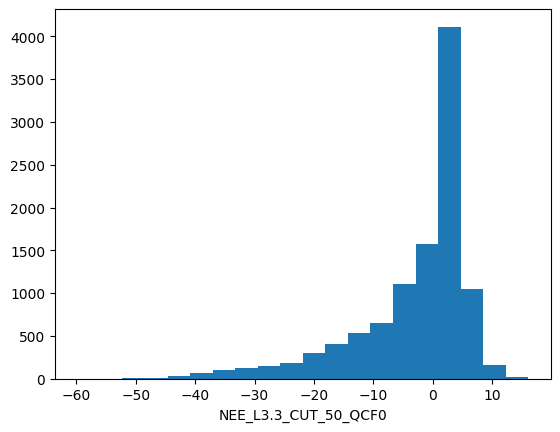

,NEE_L3.3_CUT_50_QCF0,SW_IN_POT,prec,ta,ppfd,sw_in,rh,timesince_prec,vpd,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,...,ts_0.15_gfXG_diff6h,ts_0.15_gfXG_diff12h,ts_0.15_gfXG_diff24h,ts_0.3_gfXG_diff6h,ts_0.3_gfXG_diff12h,ts_0.3_gfXG_diff24h,wfps_0.05_gfXG_diff6h,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-22 11:15:00,0.870527,508.623,0.238,3.166667,100.485834,49.333333,95.516667,0.0,0.034392,4.214833,6.794001,7.766860,50.003806,56.279186,46.719290,...,1.337738,-1.317629,-1.124065,-0.114594,-0.332553,-0.728411,3.107422,2.125116,2.928839,0.191085,0.508545,1.199013,0.861383,1.659645,2.910261
2023-11-22 11:45:00,0.844507,531.452,0.000,3.043333,78.235791,38.666667,95.280000,1.0,0.035892,3.948499,6.777297,7.739503,49.749778,56.502881,45.122243,...,1.354507,-1.310291,-1.103999,-0.151393,-0.363302,-0.746003,3.178569,1.489788,2.715081,0.431137,0.113344,1.485885,-0.853927,-1.348990,1.416971
2023-11-22 12:15:00,0.629330,539.106,0.000,3.056667,82.407674,40.666667,94.870000,2.0,0.039047,3.508604,6.869158,7.751822,50.231189,56.340153,44.602581,...,1.424386,0.177859,-0.610469,-0.182571,-0.307641,-0.746924,3.229933,2.572290,3.131318,0.380090,0.034436,1.168242,-1.600306,-1.980507,0.359746
2023-11-22 12:45:00,0.602554,531.452,0.000,3.000000,98.399892,48.333333,93.753333,3.0,0.047355,3.253336,6.856443,7.714983,49.543728,56.270616,44.413254,...,1.402835,0.531006,-0.471439,-0.234726,-0.332534,-0.798875,2.241630,1.659547,2.835273,0.118894,0.003378,1.077855,-1.631950,-1.463329,-0.060023
2023-11-22 13:15:00,0.477717,508.623,0.000,2.946667,117.173366,57.333333,93.543333,4.0,0.048761,3.404743,6.836869,7.638218,49.836477,56.365712,44.046013,...,1.406002,0.629119,-0.580503,-0.276385,-0.414082,-0.429772,2.834057,1.153027,2.859792,0.504430,0.103235,1.167029,-3.529501,-1.774765,-0.246205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,10.578562,0.000,0.017,15.693333,0.000000,0.000000,82.700000,0.0,0.308913,18.192778,18.566111,17.300000,47.839156,49.728310,45.159003,...,-0.335000,0.866111,-0.961666,0.205000,0.318334,-0.270000,-0.042154,-0.862990,-1.240195,-0.138894,-0.501428,-0.865616,-0.130630,-0.951387,-1.460515
2025-06-04 22:15:00,9.416519,0.000,0.034,15.516667,0.000000,0.000000,84.423333,0.0,0.275008,18.041666,18.451111,17.300000,47.841354,49.728310,45.154540,...,-0.538334,0.745555,-0.901111,0.199444,0.353332,-0.281666,0.030612,-0.850980,-1.201306,-0.115306,-0.455520,-0.859899,-0.075635,-0.878298,-1.447001
2025-06-04 22:45:00,10.095010,0.000,0.425,15.660000,0.000000,0.000000,83.819999,0.0,0.288298,17.903888,18.398333,17.269444,47.829346,49.721516,45.105104,...,-0.647778,0.575555,-0.836111,0.098889,0.368333,-0.310000,0.025945,-0.847119,-1.197830,-0.108815,-0.438437,-0.860283,-0.205865,-0.852473,-1.503494


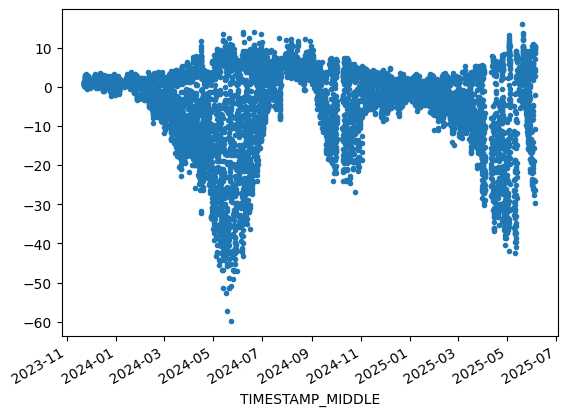

In [25]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])

# Show histogram of TARGET
plt.hist(data[TARGET], bins=20)
plt.xlabel(TARGET)
plt.show()

# Show timeseries
data[TARGET].plot(x_compat=True, style='.');

data

# CROSS-VAL SPLITS

Using stratified approach based on the target variable

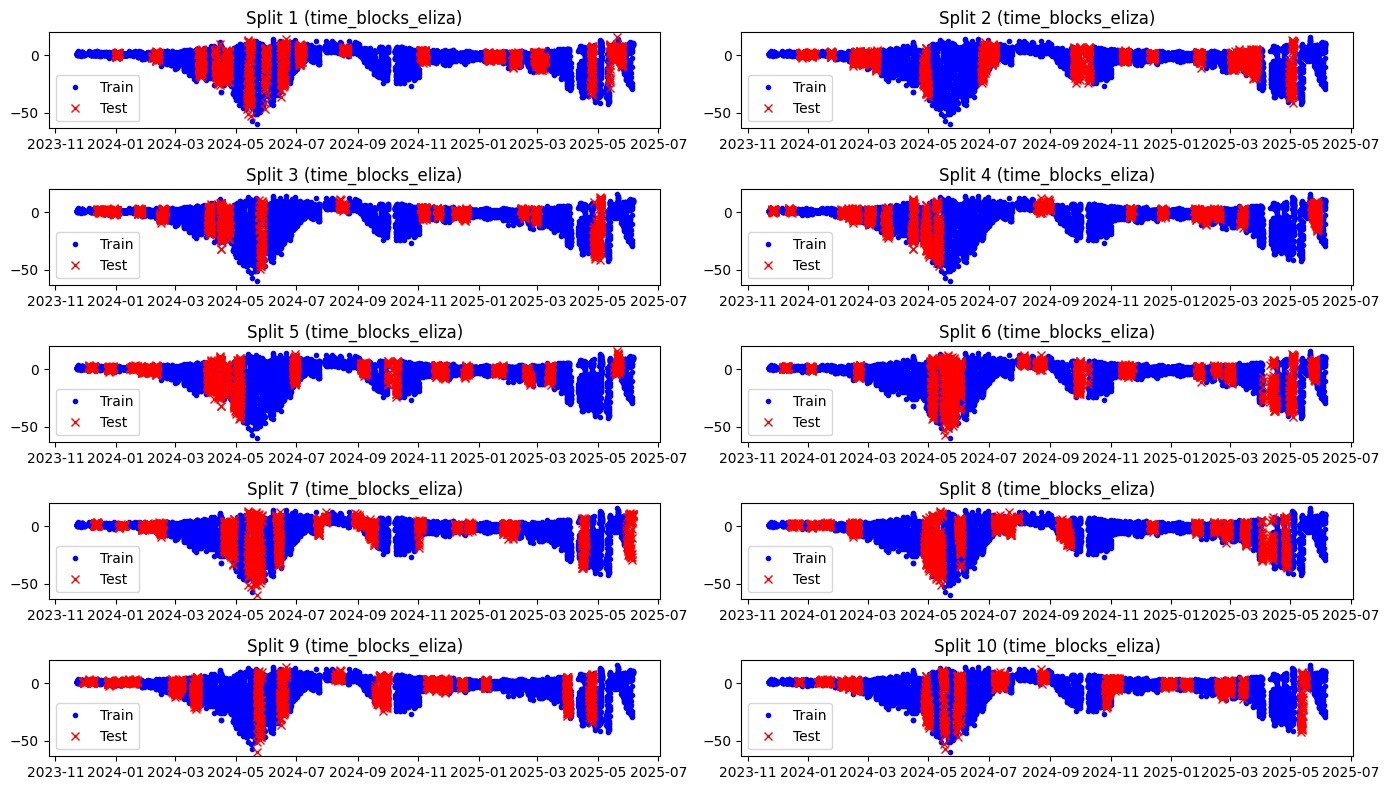

In [26]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    def create_splits(X, y, n_folds, split=0.2, mean_block=96, min_block=1, random_state=42): # you can set mean block to mean_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits
    
if CROSSVAL_SPLIT == 'custom_time_blocks':
    def create_splits(X, y, n_folds=5, test_fraction=0.2, block_duration='1D',
                    min_gap='6D', buffer_gap='1D', seed=None):
        """
        Time-block CV with buffer and min_gap enforcement, allowing partial blocks to match test_fraction.
        """
        if seed is not None:
            np.random.seed(seed)

        total_rows = len(X)
        total_test_target = int(total_rows * test_fraction)
        all_times = X.index
        block_dur = pd.to_timedelta(block_duration)
        min_gap_dur = pd.to_timedelta(min_gap)
        buffer_gap_dur = pd.to_timedelta(buffer_gap)

        # Generate all possible block start times
        possible_starts = all_times[(all_times + block_dur) <= all_times[-1]]
        splits = []

        for fold in range(n_folds):
            test_indices = set()
            buffer_indices = set()
            selected_blocks = []

            shuffled_starts = np.random.permutation(possible_starts)

            for start_time in shuffled_starts:
                end_time = start_time + block_dur
                buffer_start = start_time - buffer_gap_dur
                buffer_end = end_time + buffer_gap_dur

                # Enforce min_gap between selected test blocks
                if any(abs(pd.Timedelta(start_time - sel).total_seconds()) < min_gap_dur.total_seconds()
                    for sel in selected_blocks):
                    continue

                block_mask = (all_times >= start_time) & (all_times < end_time)
                buffer_mask = (all_times >= buffer_start) & (all_times < buffer_end)

                block_idx = np.where(block_mask)[0]
                buffer_idx = np.where(buffer_mask)[0]

                if len(block_idx) == 0:
                    continue

                # Allow trimming final block if needed
                remaining = total_test_target - len(test_indices)
                if remaining <= 0:
                    break
                if len(block_idx) > remaining:
                    block_idx = block_idx[:remaining]

                # Check again for overlap with buffer
                if any(i in buffer_indices for i in block_idx):
                    continue

                test_indices.update(block_idx)
                buffer_indices.update(buffer_idx)
                selected_blocks.append(start_time)

                if len(test_indices) >= total_test_target:
                    break

            train_indices = sorted(set(range(total_rows)) - test_indices - buffer_indices)
            splits.append((np.array(train_indices), np.array(sorted(test_indices))))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# FEATURE SELECTION

## Permutation importance

In [27]:
N_REPEATS = 5
N_RANDOMS = 10
def permutation_importance_selection(X, y, n_repeats=N_REPEATS, n_randoms=N_RANDOMS):
    iteration = 0

    # Generate random features ONCE and keep them throughout the iterations
    np.random.seed(42)  # Ensures reproducibility
    for i in range(n_randoms):
        X[f'random_{i}'] = np.random.permutation(len(X))

    while True:
        iteration += 1
        print(f"Iteration {iteration}: Starting with {X.shape[1] - n_randoms} features")

        model = RandomForestRegressor(n_estimators=100, min_samples_split=10, min_samples_leaf=5, random_state=42, n_jobs=-1) \
            if MODEL_TYPE == 'RandomForest' else XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        importance_scores, rmse_scores, r2_scores = [], [], []

        for train_idx, test_idx in cross_val_splits:
            X_train, y_train, X_test, y_test = X.iloc[train_idx], y.iloc[train_idx], X.iloc[test_idx], y.iloc[test_idx]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Invert the transformation if it was applied to calculate the performance with the original scale
            if LOG_TRANSFORM:
                y_test, y_pred = inverse_log_transform(y_test), inverse_log_transform(y_pred)

            perm_importance = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=42, n_jobs=-1)
            importance_scores.append(perm_importance.importances_mean)
            rmse_scores.append(root_mean_squared_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))

        mean_importance = np.mean(importance_scores, axis=0)
        threshold = np.mean(mean_importance[-n_randoms:])  # Use average of random features as threshold
        
        to_remove = [col for col in X.columns if mean_importance[X.columns.get_loc(col)] < threshold and not col.startswith('random_')]
        to_keep = [col for col in X.columns if col not in to_remove]
        print(f"Iteration {iteration}: Removed {len(to_remove)} features, RMSE: {np.mean(rmse_scores):.4f}, R²: {np.mean(r2_scores):.4f}")
        
        if len(to_remove) == 0:
            break  # Stop when no features are removed

        X = X[to_keep].copy()

    # Remove random features from final selection
    to_keep = [col for col in to_keep if not col.startswith('random_')]
    return to_keep


if PERMUTATION_SEL:
    to_keep = permutation_importance_selection(data.drop(columns=[TARGET]), data[TARGET])
    data = data[to_keep + [TARGET]]
    to_keep

Iteration 1: Starting with 165 features
Iteration 1: Removed 25 features, RMSE: 2.9916, R²: 0.8997
Iteration 2: Starting with 140 features
Iteration 2: Removed 9 features, RMSE: 2.9979, R²: 0.8993
Iteration 3: Starting with 131 features
Iteration 3: Removed 9 features, RMSE: 2.9947, R²: 0.8985
Iteration 4: Starting with 122 features
Iteration 4: Removed 10 features, RMSE: 2.9542, R²: 0.9019
Iteration 5: Starting with 112 features
Iteration 5: Removed 2 features, RMSE: 2.9015, R²: 0.9053
Iteration 6: Starting with 110 features
Iteration 6: Removed 10 features, RMSE: 2.9398, R²: 0.9032
Iteration 7: Starting with 100 features
Iteration 7: Removed 3 features, RMSE: 2.9092, R²: 0.9046
Iteration 8: Starting with 97 features
Iteration 8: Removed 4 features, RMSE: 2.9208, R²: 0.9040
Iteration 9: Starting with 93 features
Iteration 9: Removed 4 features, RMSE: 2.8891, R²: 0.9068
Iteration 10: Starting with 89 features
Iteration 10: Removed 2 features, RMSE: 2.9349, R²: 0.9032
Iteration 11: Star

## Recursive feature elimination

Iteration 1: Remaining features: 76, Removed: ta, RMSE: 2.8791, R²: 0.9073
Iteration 2: Remaining features: 75, Removed: ta_lag3h, RMSE: 2.8838, R²: 0.9075
Iteration 3: Remaining features: 74, Removed: rh, RMSE: 2.8839, R²: 0.9076
Iteration 4: Remaining features: 73, Removed: ta_lag9h, RMSE: 2.8893, R²: 0.9070
Iteration 5: Remaining features: 72, Removed: ts_0.05_gfXG_diff6h, RMSE: 2.9120, R²: 0.9056
Iteration 6: Remaining features: 71, Removed: ts_0.05_gfXG_lag9h_roll9hmean, RMSE: 2.9059, R²: 0.9063
Iteration 7: Remaining features: 70, Removed: vpd, RMSE: 2.9325, R²: 0.9042
Iteration 8: Remaining features: 69, Removed: ts_0.05_gfXG, RMSE: 2.9679, R²: 0.9020
Iteration 9: Remaining features: 68, Removed: ts_0.3_gfXG_diff24h, RMSE: 2.9534, R²: 0.9030
Iteration 10: Remaining features: 67, Removed: ta_lag9h_roll9hmean, RMSE: 2.9092, R²: 0.9067
Iteration 11: Remaining features: 66, Removed: ta_roll6hmean, RMSE: 2.9227, R²: 0.9054
Iteration 12: Remaining features: 65, Removed: wfps_0.15_gfXG

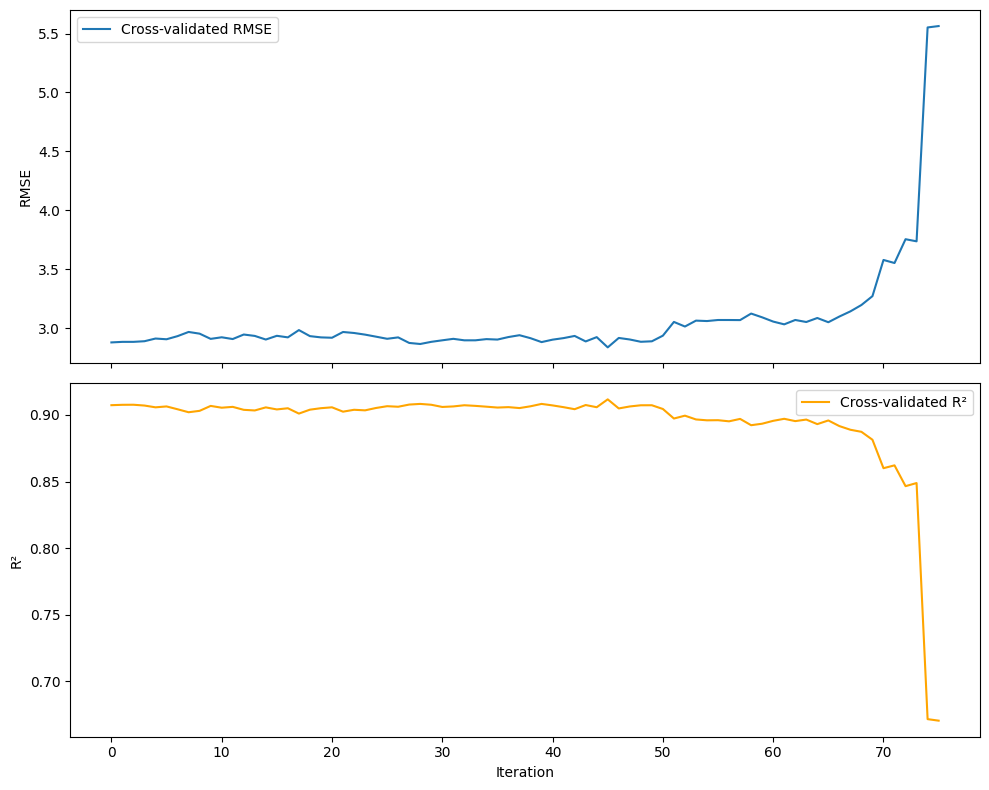


Best feature set found at iteration 66:
Selected Features: ['SW_IN_POT', 'ppfd', 'ts_0.3_gfXG', 'timesince_soil_preparation', 'timesince_harvest', 'harvest_timed', 'n_decay_timed', 'fert_timed', 'ts_0.3_gfXG_roll3hmean', 'ts_0.3_gfXG_roll6hmean', 'ts_0.05_gfXG_lag3h_roll9hmean', 'ts_0.3_gfXG_lag9h_roll9hmean']
Performance - RMSE: 3.0504, R²: 0.8958


In [28]:
def rfe_selection(X, y, cross_val_splits):
    performance = []
    iteration = 0
    features = list(X.columns)
    feature_removal_order = []  # Store removed features and their iteration index

    while len(features) > 1:
        iteration += 1
        rmse_scores, r2_scores, importances = [], [], []

        for train_idx, test_idx in cross_val_splits:
            X_train, y_train, X_test, y_test = X[features].iloc[train_idx], y.iloc[train_idx], X[features].iloc[test_idx], y.iloc[test_idx]
            model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) if MODEL_TYPE == 'RandomForest' else XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            # Invert the transformation if it was applied to calculate the performance with the original scale
            if LOG_TRANSFORM:
                y_test, y_pred = inverse_log_transform(y_test), inverse_log_transform(y_pred)
            
            rmse_scores.append(root_mean_squared_error(y_test, y_pred))
            r2_scores.append(r2_score(y_test, y_pred))
            importances.append(model.feature_importances_)

        mean_rmse = np.mean(rmse_scores)
        mean_r2 = np.mean(r2_scores)
        performance.append((features.copy(), mean_rmse, mean_r2))

        mean_importances = np.mean(importances, axis=0)
        least_important_index = np.argmin(mean_importances)
        least_important_feature = features.pop(least_important_index)

        # Store the removed feature with its iteration index
        feature_removal_order.append((least_important_feature, iteration))

        print(f"Iteration {iteration}: Remaining features: {len(features)}, Removed: {least_important_feature}, RMSE: {mean_rmse:.4f}, R²: {mean_r2:.4f}")

    # Extract RMSE and R² values
    rmse_values = [score[1] for score in performance]
    r2_values = [score[2] for score in performance]

    # Plot RMSE and R² over iterations
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    axs[0].plot(range(len(performance)), rmse_values, label="Cross-validated RMSE")
    axs[0].set_ylabel("RMSE")
    axs[0].legend()

    axs[1].plot(range(len(performance)), r2_values, label="Cross-validated R²", color="orange")
    axs[1].set_xlabel("Iteration")
    axs[1].set_ylabel("R²")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # Select best feature set by minimizing both R² and RMSE and penlizing larger feature sets
    # Normalize RMSE and R²
    norm_rmse = (np.array(rmse_values) - min(rmse_values)) / (max(rmse_values) - min(rmse_values))
    norm_r2 = (np.array(r2_values) - min(r2_values)) / (max(r2_values) - min(r2_values))
    # Set weights for normalized metrics
    w_rmse, w_r2, w_penalty = 0.5, 0.5, 0.01  # Adjust w_penalty as needed
    # Calculate composite scores with normalized metrics and feature count penalty
    composite_scores = [
        (performance[i][0], # Features
         i + 1, # Iteration number
        w_rmse * norm_rmse[i] + w_r2 * (1 - norm_r2[i]) + w_penalty * len(performance[i][0])  # Composite score
        )  
        for i in range(len(performance))
    ]

    # Find the feature subset with the best (lowest) composite score
    best_features, best_iteration, _ = min(composite_scores, key=lambda x: x[2])

    # Add the final remaining feature
    feature_removal_order.append((features[0], iteration + 1))

    # Rank features based on removal order
    feature_ranking = [feature for feature, _ in sorted(feature_removal_order, key=lambda x: x[1], reverse=True)]

    # Print the best feature set details
    print(f"\nBest feature set found at iteration {best_iteration}:")
    print(f"Selected Features: {best_features}")
    print(f"Performance - RMSE: {rmse_values[best_iteration-1]:.4f}, R²: {r2_values[best_iteration-1]:.4f}")

    return best_features, feature_ranking

if RFE_SEL:
    selected_features, ranked_features = rfe_selection(data.drop(columns=[TARGET]), data[TARGET], cross_val_splits= cross_val_splits)
    # Update the main dataframe
    data = data[selected_features + [TARGET]]

# EXPORT 

In [29]:
filename = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(filename, 'w') as f:
    for item in selected_features:
        f.write(f"{item}\n")

filename = 'ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(filename, 'w') as f:
    for item in ranked_features:
        f.write(f"{item}\n")

# **End of notebook**

In [30]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2025-09-25 19:23:07
